# Flash-Aurora: Typhoon Dolphin with recent HRES $0.1^\circ$ analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CatManJr/Flash-Aurora/blob/main/docs/example_tc_dolphin_hres01_colab.ipynb)

**台风白海豚** / **Typhoon Dolphin** (2613 / WP122026), using the **most recent NSF NCAR GDEX IFS HRES $0.1^\circ$ analysis day** available at runtime as the initial condition, preset `hres_0.1` (`aurora-0.1-finetuned`), Microsoft Aurora eye tracker, and JTWC b-deck verification.

This is a sibling of [`example_tc_dolphin_colab.ipynb`](example_tc_dolphin_colab.ipynb) (ERA5 + Aurora 1.5). Here the IC is **operational analysis** at $0.1^\circ$, closer in spirit to high-resolution Aurora fine-tuning (Analysis, not HRES T0).

### Before you start
1. **GPU:** single device needs about **$80+$ GiB** reserved for `hres_0.1`. On smaller cards set `DISTRIBUTED = DistributedConfig(devices=("cuda:0", "cuda:1"))`.
2. Colab **Secrets** (optional): `HF_TOKEN`. No CDS key is required for this preset.
3. Install `flash-aurora`, restart the runtime, then continue from discovery / setup.
4. NSF NCAR GDEX `d113001` (`data.gdex.ucar.edu`) typically lags real time by several days. The first code cell **probes** the newest day with a surface GRIB GET; if probing fails, it falls back to a documented recent day. Legacy `data.rda.ucar.edu` URLs currently return HTTP 403.

### Notes
- Medium-range default: **10 days** (`FORECAST_DAYS`). Load uses `LOAD_VRAM_STEPS = 1` so the VRAM guard does not scale with horizon.
- Tracker seed eye is taken from JTWC BEST at the IC time when the b-deck is reachable.
- We thank Microsoft Research for Aurora and the tracker design.

## 0. Install dependencies

In [1]:
# After success: Runtime -> Restart session, then skip this cell.
# Assumes cutlass Python is already present; we do not reinstall it.
import sys
print("python:", sys.version)
!nvidia-smi || true

%pip install -q --upgrade pip
%pip install -U -q "flash-aurora"
%pip install -U -q "nvidia-cutlassdsl==4.5.2"

from importlib.metadata import version
import cutlass
import torch

print("flash_aurora:", version("flash-aurora"))
print("cutlass:", cutlass.__file__)
print(
    "torch:",
    torch.__version__,
    "cuda:",
    torch.cuda.is_available(),
    torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    f"VRAM={torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GiB"
    if torch.cuda.is_available()
    else "",
)
assert torch.cuda.is_available(), "Enable a GPU runtime before continuing."
print("Restart the runtime now, then continue from the next code cell.")

python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Sun Aug  9 08:41:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             76W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             

## 1. Discover the latest HRES $0.1^\circ$ analysis day and set up the engine

Probe NSF NCAR GDEX (`data.gdex.ucar.edu/d113001`) for the newest `ec.oper.an.sfc` MSL GRIB. Use 06 UTC as the IC (`TIME_INDEX=1`, history 00Z+06Z).

In [2]:
from __future__ import annotations

from datetime import datetime, timedelta, timezone
from pathlib import Path
import os

import requests

from flash_aurora.engine import (
    AuroraEngine,
    DataDownloader,
    DEFAULT_PRESETS,
    HF_MIRROR_ENDPOINT,
    InitialConditionBuilder,
)
from flash_aurora.engine.core.redaction import safe_path
from flash_aurora.engine.distributed import DistributedConfig
from flash_aurora.engine.ingress.download.grib_ifs import surf_grib_url
from flash_aurora.engine.ingress.download.http import _activate_ucar_insecure_tls

PRESET = "hres_0.1"
INFERENCE_PRECISION = "bf16_mixed@fp32"
FORECAST_DAYS = 10
TIME_INDEX = 1  # 06 UTC IC with pair policy (00Z + 06Z)
FALLBACK_DAY = datetime(2026, 7, 29)  # last day reported on GDEX metadata when drafting this notebook
PROBE_LOOKBACK_DAYS = 45

STORM_NAME_EN = "Typhoon Dolphin"
STORM_NAME_ZH = "台风白海豚"
STORM_ID_WMO = "2613"
STORM_ID_JTWC = "WP122026"

# Single GPU: None.
# DISTRIBUTED = DistributedConfig(devices=("cuda:0", "cuda:1")) to trigger Dual-GPU PP
DISTRIBUTED = None

ASSET_ROOT = Path("/content/assets").resolve()
ASSET_ROOT.mkdir(parents=True, exist_ok=True)

try:
    from google.colab import userdata
    for key in ("HF_TOKEN",):
        try:
            value = userdata.get(key)
        except Exception:
            value = None
        if value and not os.environ.get(key):
            os.environ[key] = value
            print(f"loaded Colab secret: {key}")
except ImportError:
    pass


def probe_latest_hres01_day(
    *,
    lookback_days: int = PROBE_LOOKBACK_DAYS,
    fallback: datetime = FALLBACK_DAY,
) -> datetime:
    """Return the most recent UTC calendar day with a reachable GDEX surface analysis GRIB."""
    _activate_ucar_insecure_tls()
    today = datetime.now(timezone.utc).replace(tzinfo=None, hour=0, minute=0, second=0, microsecond=0)
    for offset in range(0, lookback_days + 1):
        day = today - timedelta(days=offset)
        url = surf_grib_url(day, "msl")
        try:
            response = requests.get(url, stream=True, timeout=45, verify=False)
            status = response.status_code
            length = response.headers.get("Content-Length")
            if status == 200:
                next(response.iter_content(4096), None)
                response.close()
                print(f"latest HRES 0.1 analysis day: {day.date()} (GDEX OK, bytes~{length})")
                return day
            response.close()
            if offset < 5 or offset % 5 == 0:
                print(f"  probe {day.date()}: HTTP {status}")
        except Exception as exc:  # noqa: BLE001
            if offset < 5 or offset % 5 == 0:
                print(f"  probe {day.date()}: {type(exc).__name__}: {exc}")
    print(f"probe failed; falling back to {fallback.date()}")
    return fallback.replace(hour=0, minute=0, second=0, microsecond=0)


analysis_day = probe_latest_hres01_day()
VALID_TIME = analysis_day.replace(hour=6, minute=0, second=0, microsecond=0)
FORECAST_END = VALID_TIME + timedelta(days=FORECAST_DAYS)
ROLLOUT_STEPS = FORECAST_DAYS * 4  # 6-hourly
assert ROLLOUT_STEPS == int((FORECAST_END - VALID_TIME).total_seconds() // 3600 // 6)

USE_HF_MIRROR = False
variant = DEFAULT_PRESETS.get(PRESET).variant
local_checkpoint = ASSET_ROOT / variant.checkpoint_filename
local_static = ASSET_ROOT / variant.static_pickle if variant.static_pickle else None

if local_checkpoint.is_file():
    checkpoint_arg = local_checkpoint
    allow_hub_download = False
    hf_endpoint = None
    print("checkpoint:", safe_path(local_checkpoint))
else:
    checkpoint_arg = None
    allow_hub_download = True
    hf_endpoint = HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None
    print("checkpoint not found locally; will download from Hugging Face")
    print("  target dir:", safe_path(ASSET_ROOT))
    print("  hf_endpoint:", hf_endpoint or "https://huggingface.co")

if local_static is not None and local_static.is_file():
    print("static pickle:", safe_path(local_static))
else:
    print("static pickle: will download with the engine / HF hub if missing")

downloader = DataDownloader.from_preset(PRESET, asset_root=ASSET_ROOT)
engine = AuroraEngine.from_preset(
    PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=checkpoint_arg,
    allow_hub_download=allow_hub_download,
    hf_endpoint=hf_endpoint,
    inference_precision=INFERENCE_PRECISION,
    distributed=DISTRIBUTED,
)

print(f"{STORM_NAME_EN} / {STORM_NAME_ZH}  {STORM_ID_WMO} / {STORM_ID_JTWC}")
print("preset:", PRESET, "| model:", engine.config.variant.name)
print("IC:", VALID_TIME.isoformat(), "UTC")
print("forecast days:", FORECAST_DAYS, "| end:", FORECAST_END.isoformat(), "UTC")
print("rollout steps:", ROLLOUT_STEPS, f"(+{ROLLOUT_STEPS * 6} h)")
print("cache_dir:", safe_path(downloader.resolve_cache_dir()))
print("asset_root:", safe_path(ASSET_ROOT))
print("distributed:", DISTRIBUTED)

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: UserWarning: UCAR/GDEX TLS certificate verification failed; continuing without verification for data.gdex.ucar.edu, data.rda.ucar.edu only in this process. Set FLASH_AURORA_SSL_VERIFY=0 to skip verification from the first request.
  exec(code_obj, self.user_global_ns, self.user_ns)


  probe 2026-08-09: HTTP 404
  probe 2026-08-08: HTTP 404
  probe 2026-08-07: HTTP 404
  probe 2026-08-06: HTTP 404
latest HRES 0.1 analysis day: 2026-08-05 (GDEX OK, bytes~None)
checkpoint: aurora-0.1-finetuned.ckpt
static pickle: aurora-0.1-static.pickle
Typhoon Dolphin / 台风白海豚  2613 / WP122026
preset: hres_0.1 | model: aurora-0.1-finetuned
IC: 2026-08-05T06:00:00 UTC
forecast days: 10 | end: 2026-08-15T06:00:00 UTC
rollout steps: 40 (+240 h)
cache_dir: hres_0.1
asset_root: assets
distributed: None


## 2. Download IFS HRES $0.1^\circ$ analysis (NSF NCAR GDEX)

`DataDownloader.ensure()` pulls surface and pressure-level GRIB for the analysis day and materialises NetCDF intermediates under `<ASSET_ROOT>/hres_0.1/`. Downloads are large.

In [3]:
result = downloader.ensure(VALID_TIME)
print("downloaded:", result.downloaded)
print("skipped:", result.skipped)
for key, path in result.paths.items():
    print(f"  {key}: {safe_path(path)}")

downloaded: ()
skipped: ('surface', 'atmospheric_00', 'atmospheric_06')
  surface: 2026-08-05-surface-level.nc
  atmospheric_00: 2026-08-05-atmospheric-00.nc
  atmospheric_06: 2026-08-05-atmospheric-06.nc


## 3. Build IC, roll out, and track

Seed the tracker from JTWC BEST at the IC time when possible; otherwise use a fallback near the late-July Dolphin track.

In [4]:
from __future__ import annotations

import dataclasses
import gc
import math
import os
from datetime import datetime
from pathlib import Path
from urllib.request import Request, urlopen

import pandas as pd
import torch

from flash_aurora import Tracker
from flash_aurora.models.aurora.batch import Batch
from flash_aurora.models.aurora.rollout import advance_rollout_batch
from flash_aurora.models.aurora.tracker import NoEyeException

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

BDECK_URLS = (
    "https://hurricanes.ral.ucar.edu/realtime/plots/northwestpacific/2026/wp122026/bwp122026.dat",
    "https://hurricanes.ral.ucar.edu/repository/data/bdecks_open/2026/bwp122026.dat",
)
BDECK_PATH = ASSET_ROOT / "bwp122026.dat"
CHUNK_STEPS = 8

CMA_GRADES = (
    (17.2, "TD", "Tropical Depression", "#5B8FA8"),
    (24.5, "TS", "Tropical Storm", "#3D9B6E"),
    (32.7, "STS", "Severe Tropical Storm", "#C4A035"),
    (41.5, "TY", "Typhoon", "#D47B2A"),
    (51.0, "STY", "Severe Typhoon", "#C23B2A"),
    (float("inf"), "SuperTY", "Super Typhoon", "#6B2D7B"),
)


def cma_grade(wind_ms: float) -> tuple[str, str, str]:
    for upper, code, label, color in CMA_GRADES:
        if wind_ms < upper:
            return code, label, color
    return CMA_GRADES[-1][1], CMA_GRADES[-1][2], CMA_GRADES[-1][3]


def _parse_atcf_lat(token: str) -> float:
    token = token.strip()
    hem = token[-1].upper()
    value = int(token[:-1]) / 10.0
    return -value if hem == "S" else value


def _parse_atcf_lon(token: str) -> float:
    token = token.strip()
    hem = token[-1].upper()
    value = int(token[:-1]) / 10.0
    if hem == "W":
        value = -value
    return value % 360.0


def download_bdeck(path: Path) -> Path:
    if path.is_file() and path.stat().st_size > 0:
        print("using cached b-deck:", path)
        return path
    last_err: Exception | None = None
    for url in BDECK_URLS:
        try:
            req = Request(url, headers={"User-Agent": "flash-aurora-hres01-notebook"})
            with urlopen(req, timeout=60) as resp:
                text = resp.read().decode("utf-8", errors="replace")
            if "BEST" not in text:
                raise RuntimeError(f"unexpected b-deck from {url}")
            path.write_text(text)
            print("downloaded b-deck:", url)
            return path
        except Exception as exc:  # noqa: BLE001
            last_err = exc
            print("failed:", url, "->", exc)
    raise RuntimeError(f"could not download b-deck: {last_err}")


def load_jtwc_bdeck(path: Path) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for line in path.read_text().splitlines():
        parts = [p.strip() for p in line.split(",")]
        if len(parts) < 10 or parts[4] != "BEST":
            continue
        try:
            tau = int(parts[5])
        except ValueError:
            continue
        if tau != 0:
            continue
        rows.append(
            {
                "time": datetime.strptime(parts[2], "%Y%m%d%H"),
                "lat": _parse_atcf_lat(parts[6]),
                "lon": _parse_atcf_lon(parts[7]),
                "wind_kt": float(parts[8]) if parts[8] else math.nan,
                "mslp_hpa": float(parts[9]) if parts[9] not in {"", "-999"} else math.nan,
            }
        )
    if not rows:
        raise RuntimeError("no BEST tau=0 fixes in b-deck")
    return pd.DataFrame(rows).drop_duplicates("time").sort_values("time").reset_index(drop=True)


def _release_cuda() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()


def _as_next_ic(state: Batch, pred: Batch, patch_size: int) -> Batch:
    """Rebuild a validator-safe 2-frame IC from AR state + latest prediction."""
    state = state.crop(patch_size)
    pred32 = pred.type(torch.float32)
    state32 = state.type(torch.float32)
    nxt = advance_rollout_batch(state32, pred32)
    nxt = dataclasses.replace(
        nxt,
        metadata=dataclasses.replace(nxt.metadata, rollout_step=0),
    )
    # crop/cat views are often non-contiguous; validator requires contiguous.
    return nxt._fmap(lambda t: t.contiguous())


jtwc = load_jtwc_bdeck(download_bdeck(BDECK_PATH))
seed = jtwc[jtwc["time"] == VALID_TIME]
if len(seed):
    INIT_LAT = float(seed.iloc[0]["lat"])
    INIT_LON = float(seed.iloc[0]["lon"])
    print("JTWC seed at IC:", INIT_LAT, INIT_LON, f"({seed.iloc[0]['wind_kt']} kt)")
else:
    INIT_LAT, INIT_LON = 14.5, 168.4
    print("JTWC has no BEST at IC; using fallback seed:", INIT_LAT, INIT_LON)

request = downloader.ingest_request(VALID_TIME, time_index=TIME_INDEX, download=False)
batch = InitialConditionBuilder(engine.config).from_source(request)
print("IC time:", batch.metadata.time)
print("spatial:", batch.spatial_shape)
assert 700 in batch.metadata.atmos_levels, "tracker needs 700 hPa geopotential"
assert "lsm" in batch.static_vars, "land-sea mask required"

tracker = Tracker(init_lat=INIT_LAT, init_lon=INIT_LON, init_time=VALID_TIME)

LOAD_VRAM_STEPS = 1
engine.load(rollout_steps=LOAD_VRAM_STEPS)
PATCH = int(engine.model.patch_size)  # 10 for AuroraHighRes
print("loaded model:", type(engine.model).__name__)
print("device:", next(engine.model.parameters()).device)
print(
    "vram budget steps:", LOAD_VRAM_STEPS,
    "| forecast steps:", ROLLOUT_STEPS,
    "| chunk:", CHUNK_STEPS,
)
_release_cuda()

preds: list[Batch] = []
state = batch.crop(PATCH).type(torch.float32)._fmap(lambda t: t.contiguous())
step_i = 0
lost_eye = False

with torch.inference_mode():
    while step_i < ROLLOUT_STEPS and not lost_eye:
        n = min(CHUNK_STEPS, ROLLOUT_STEPS - step_i)
        _release_cuda()
        for pred in engine.rollout_stream(state, n):
            step_i += 1
            pred_cpu = pred.to("cpu")
            del pred
            _release_cuda()

            preds.append(pred_cpu)
            state = _as_next_ic(state, pred_cpu, PATCH)

            try:
                tracker.step(pred_cpu)
            except NoEyeException as exc:
                print(f"tracker lost the eye at step {step_i}: {exc}")
                lost_eye = True
                break

            point = tracker.results().iloc[-1]
            code, _, _ = cma_grade(float(point.wind))
            if step_i == 1 or step_i == ROLLOUT_STEPS or step_i % 4 == 0:
                free_gib = torch.cuda.mem_get_info(0)[0] / 1024**3
                print(
                    f"step {step_i:02d}/{ROLLOUT_STEPS}  {point.time}  "
                    f"{point.lat:.2f}N {point.lon:.2f}E  "
                    f"{point.msl/100:.1f} hPa  {point.wind:.1f} m/s  {code}  "
                    f"free={free_gib:.1f} GiB"
                )
        _release_cuda()

track = tracker.results().copy()
track["msl_hpa"] = track["msl"] / 100.0
track["lead_h"] = [int((t - VALID_TIME).total_seconds() // 3600) for t in track["time"]]
grade_rows = [cma_grade(float(w)) for w in track["wind"]]
track["grade"] = [g[0] for g in grade_rows]
track["grade_label"] = [g[1] for g in grade_rows]
track["grade_color"] = [g[2] for g in grade_rows]
print("track points:", len(track), "| first:", track["time"].iloc[0], "| last:", track["time"].iloc[-1])
display(track[["time", "lead_h", "lat", "lon", "msl_hpa", "wind", "grade"]])

using cached b-deck: /content/assets/bwp122026.dat
JTWC seed at IC: 25.6 137.2 (100.0 kt)
IC time: (datetime.datetime(2026, 8, 5, 6, 0),)
spatial: torch.Size([1801, 3600])
loaded model: AuroraHighRes
device: cuda:0
vram budget steps: 1 | forecast steps: 40 | chunk: 8
step 01/40  2026-08-05 12:00:00  26.80N 135.70E  955.0 hPa  29.9 m/s  STS  free=57.9 GiB
step 04/40  2026-08-06 06:00:00  27.30N 131.10E  952.3 hPa  29.0 m/s  STS  free=54.4 GiB
step 08/40  2026-08-07 06:00:00  27.30N 126.20E  956.7 hPa  24.9 m/s  STS  free=51.3 GiB
step 12/40  2026-08-08 06:00:00  26.70N 122.90E  961.9 hPa  24.8 m/s  STS  free=48.1 GiB
step 16/40  2026-08-09 06:00:00  24.90N 118.50E  987.5 hPa  8.7 m/s  TD  free=48.1 GiB
step 20/40  2026-08-10 06:00:00  25.70N 115.70E  992.4 hPa  3.4 m/s  TD  free=48.1 GiB
step 24/40  2026-08-11 06:00:00  26.20N 113.70E  996.4 hPa  3.7 m/s  TD  free=48.1 GiB
step 28/40  2026-08-12 06:00:00  26.90N 113.90E  997.0 hPa  4.3 m/s  TD  free=48.1 GiB
step 32/40  2026-08-13 06:00

,time,lead_h,lat,lon,msl_hpa,wind,grade
0,2026-08-05 06:00:00,0,25.600000,137.200000,NaN,NaN,SuperTY
1,2026-08-05 12:00:00,6,26.799999,135.699997,954.995703,29.925133,STS
2,2026-08-05 18:00:00,12,27.200001,134.100006,954.317578,29.100294,STS
3,2026-08-06 00:00:00,18,27.299999,132.500000,954.159688,30.581358,STS
4,2026-08-06 06:00:00,24,27.299999,131.100006,952.332813,28.986616,STS
5,2026-08-06 12:00:00,30,27.100000,129.800003,955.465156,27.650229,STS
6,2026-08-06 18:00:00,36,26.400000,128.500000,956.690078,24.522202,STS
7,2026-08-07 00:00:00,42,27.299999,127.099998,956.816953,25.377279,STS
8,2026-08-07 06:00:00,48,27.299999,126.199997,956.663828,24.939646,STS
9,2026-08-07 12:00:00,54,27.299999,125.400002,957.358281,25.212303,STS


## 4. Full track map with land

Western North Pacific domain sized for an open-ocean IC near $165^\circ\mathrm{E}$--$170^\circ\mathrm{E}$ and a 10-day westward track.

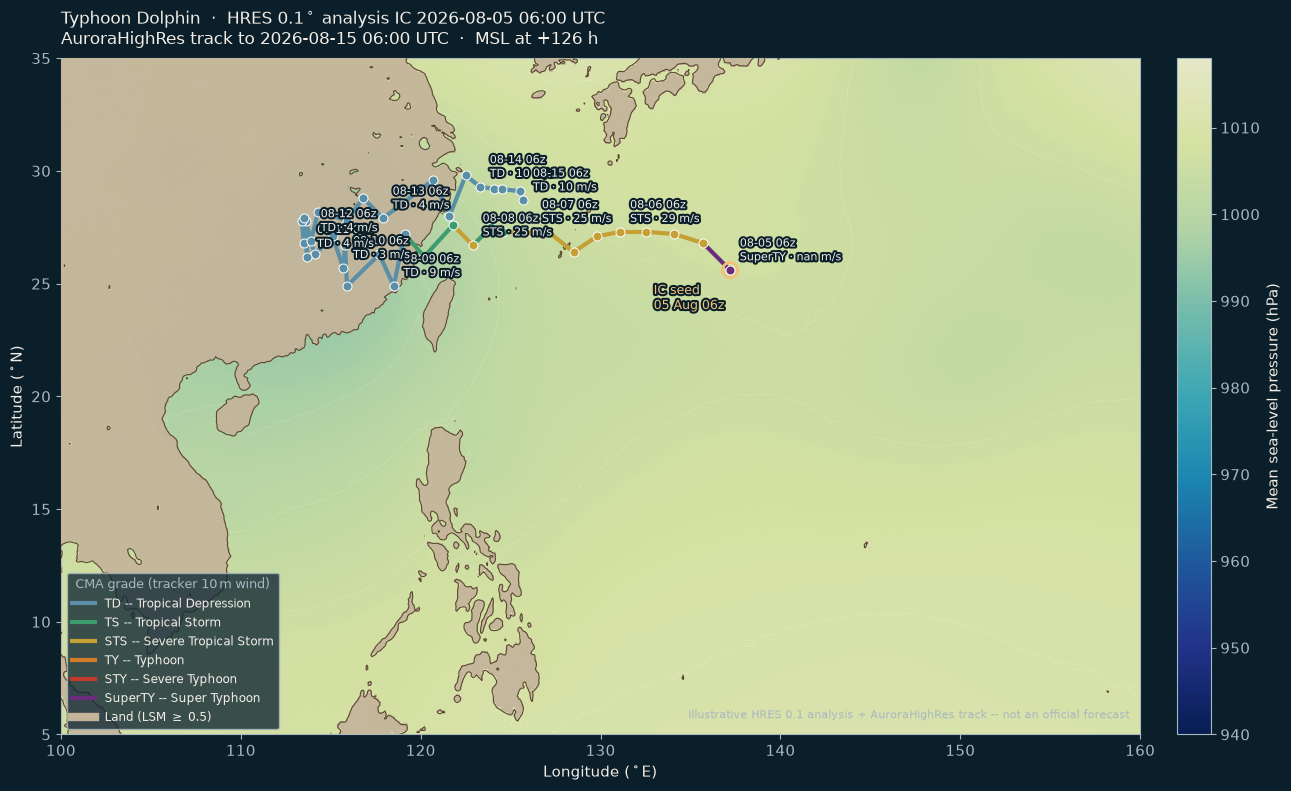

In [5]:
from __future__ import annotations

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

SEA = "#0B1F2A"
LAND = "#C4B49A"
TEXT = "#F2EDE6"
MUTED = "#A8B7C0"
MSL_CMAP = "YlGnBu_r"

# Open-Pacific domain for a late-July Dolphin IC
LON_MIN, LON_MAX = 100.0, 160.0
LAT_MIN, LAT_MAX = 5.0, 35.0

lsm = batch.static_vars["lsm"].detach().cpu().numpy()
lat_full = batch.metadata.lat.detach().cpu().numpy()
lon_full = batch.metadata.lon.detach().cpu().numpy()
# Aurora lon may be 0..360 already after regrid
lon_plot = np.mod(lon_full, 360.0)

bg_idx = min(len(preds) - 1, max(0, len(preds) // 2))
bg = preds[bg_idx]
msl_full = bg.surf_vars["msl"][0, 0].detach().cpu().numpy() / 100.0

lat_mask = (lat_full >= LAT_MIN) & (lat_full <= LAT_MAX)
lon_mask = (lon_plot >= LON_MIN) & (lon_plot <= LON_MAX)
lat_crop = lat_full[lat_mask]
lon_crop = lon_plot[lon_mask]
msl_crop = msl_full[np.ix_(lat_mask, lon_mask)]
lsm_crop = lsm[np.ix_(lat_mask, lon_mask)].copy()
lat_ascending = bool(lat_crop[0] < lat_crop[-1])
if lat_ascending:
    msl_crop = msl_crop[::-1]
    lsm_crop = lsm_crop[::-1]
    lat_crop = lat_crop[::-1]

plt.rcParams.update({
    "figure.facecolor": SEA,
    "axes.facecolor": SEA,
    "savefig.facecolor": SEA,
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "axes.edgecolor": MUTED,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 11,
    "mathtext.default": "regular",
})

fig, ax = plt.subplots(figsize=(12.8, 7.8), constrained_layout=True)
extent = (float(lon_crop.min()), float(lon_crop.max()), float(lat_crop.min()), float(lat_crop.max()))

mesh = ax.imshow(
    msl_crop,
    extent=extent,
    origin="upper",
    aspect="auto",
    cmap=MSL_CMAP,
    vmin=940,
    vmax=1018,
    interpolation="bilinear",
    alpha=0.90,
    zorder=1,
)
lon_grid, lat_grid = np.meshgrid(lon_crop, lat_crop)
ax.contour(
    lon_grid, lat_grid, msl_crop,
    levels=np.arange(950, 1016, 4), colors="white", linewidths=0.3, alpha=0.30, zorder=2,
)

land_cmap = ListedColormap(["none", LAND])
ax.imshow(
    (lsm_crop >= 0.5).astype(float),
    extent=extent, origin="upper", aspect="auto", cmap=land_cmap,
    vmin=0, vmax=1, interpolation="nearest", zorder=3, alpha=0.92,
)
ax.contour(lon_grid, lat_grid, lsm_crop, levels=[0.5], colors="#5A4632", linewidths=0.8, zorder=4)

points = np.column_stack([track["lon"].to_numpy(), track["lat"].to_numpy()])
if len(points) >= 2:
    segments = np.stack([points[:-1], points[1:]], axis=1)
    ax.add_collection(
        LineCollection(
            segments,
            colors=track["grade_color"].to_numpy()[:-1],
            linewidths=3.0,
            capstyle="round",
            zorder=5,
        )
    )

halo = [pe.withStroke(linewidth=3.0, foreground=SEA)]
label_idx = {0, len(track) - 1}
label_idx.update(i for i, lead in enumerate(track["lead_h"]) if int(lead) % 24 == 0)
for pos, row in enumerate(track.itertuples()):
    ax.scatter(row.lon, row.lat, s=42, c=row.grade_color, edgecolors="white", linewidths=0.7, zorder=6)
    if pos in label_idx:
        ax.annotate(
            rf"{row.time.strftime('%m-%d %Hz')}" + "\n" + rf"{row.grade} ${{\cdot}}$ {row.wind:.0f} m/s",
            (row.lon, row.lat),
            textcoords="offset points",
            xytext=(7, 7),
            fontsize=8,
            color=TEXT,
            path_effects=halo,
            zorder=7,
        )

ax.scatter([INIT_LON], [INIT_LAT], s=120, facecolors="none", edgecolors="#F0C27A", linewidths=2.0, zorder=8)
ax.annotate(
    "IC seed\n" + VALID_TIME.strftime("%d %b %Hz"),
    (INIT_LON, INIT_LAT),
    textcoords="offset points",
    xytext=(-55, -28),
    fontsize=9,
    color="#F0C27A",
    path_effects=halo,
)

ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel(r"Longitude ($^\circ$E)")
ax.set_ylabel(r"Latitude ($^\circ$N)")
ax.set_title(
    rf"{STORM_NAME_EN}  ${{\cdot}}$  HRES $0.1^\circ$ analysis IC {VALID_TIME.strftime('%Y-%m-%d %H:%M')} UTC"
    "\n"
    rf"AuroraHighRes track to {track['time'].iloc[-1].strftime('%Y-%m-%d %H:%M')} UTC"
    rf"  ${{\cdot}}$  MSL at +{(bg_idx + 1) * 6} h",
    loc="left",
    fontsize=12,
    pad=10,
)
cbar = fig.colorbar(mesh, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Mean sea-level pressure (hPa)")

legend_handles = [
    Line2D([0], [0], color=color, lw=3, label=f"{code} -- {label}")
    for _, code, label, color in CMA_GRADES
]
legend_handles.append(Line2D([0], [0], color=LAND, lw=6, label=r"Land (LSM $\geq$ 0.5)"))
leg = ax.legend(
    handles=legend_handles,
    title=r"CMA grade (tracker $10\,\mathrm{m}$ wind)",
    loc="lower left",
    frameon=True,
    facecolor="#122A36",
    edgecolor=MUTED,
    labelcolor=TEXT,
    fontsize=8.5,
    title_fontsize=9,
)
leg.get_title().set_color(MUTED)
ax.text(
    0.99, 0.02,
    "Illustrative HRES 0.1 analysis + AuroraHighRes track -- not an official forecast",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color=MUTED,
)
plt.show()

## 5. Daily MSL and track panels

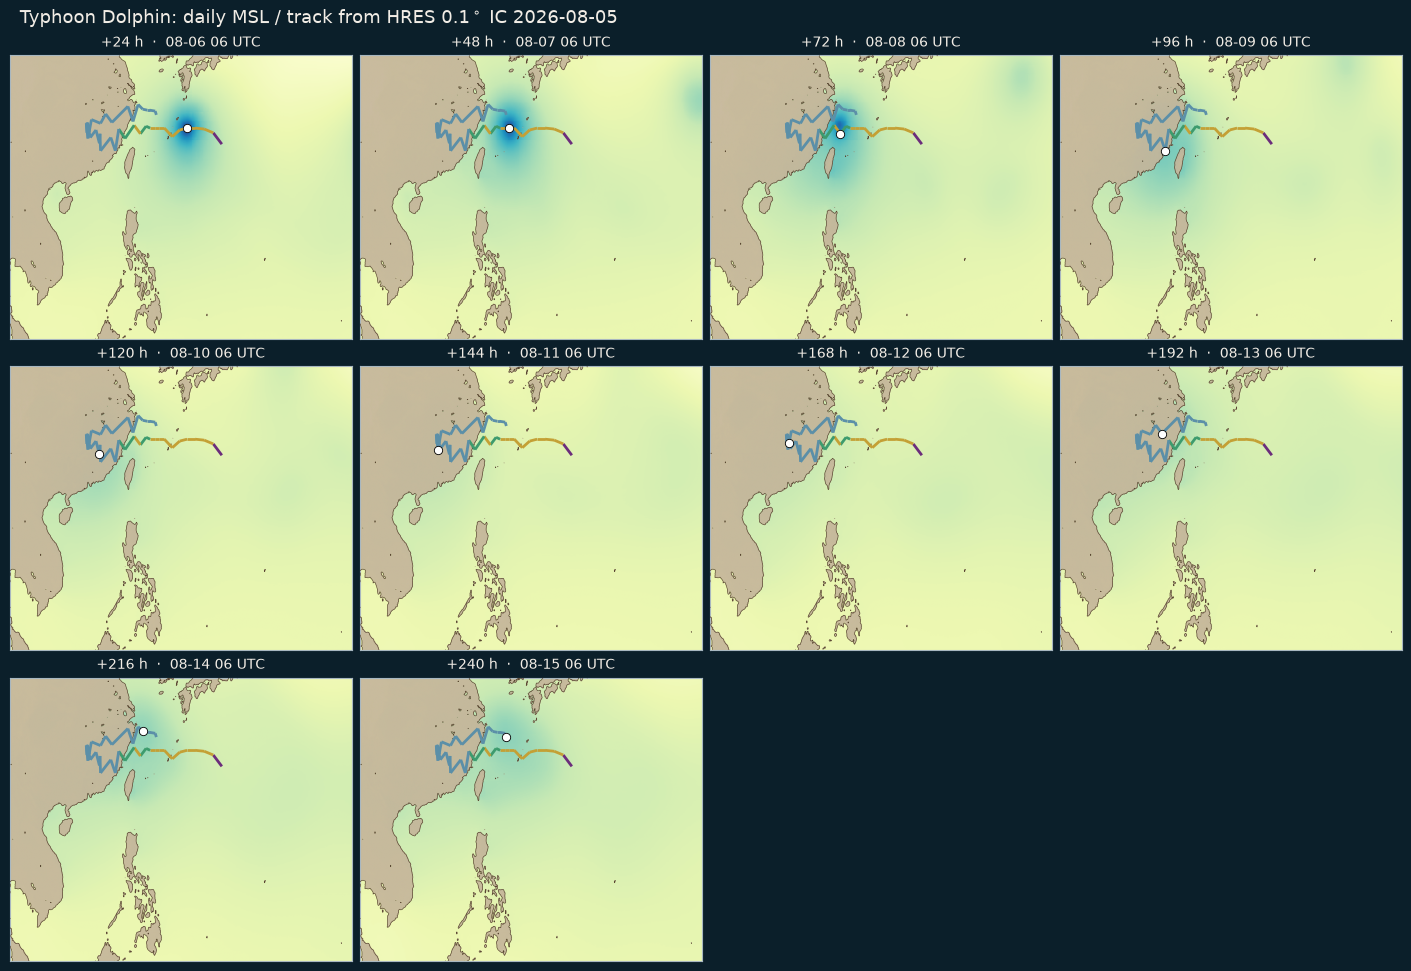

In [6]:
daily_leads = list(range(24, ROLLOUT_STEPS * 6 + 1, 24))
panel_specs = [(lead, lead // 6 - 1) for lead in daily_leads if 0 <= lead // 6 - 1 < len(preds)]

ncols = 4
nrows = int(np.ceil(len(panel_specs) / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows), squeeze=False, constrained_layout=True)
for ax in axs.ravel():
    ax.set_facecolor(SEA)
    ax.axis("off")

for panel_i, (lead, idx) in enumerate(panel_specs):
    ax = axs[panel_i // ncols, panel_i % ncols]
    ax.axis("on")
    pred = preds[idx]
    msl = pred.surf_vars["msl"][0, 0].detach().cpu().numpy() / 100.0
    msl_c = msl[np.ix_(lat_mask, lon_mask)]
    lsm_c = lsm[np.ix_(lat_mask, lon_mask)].copy()
    if lat_ascending:
        msl_c = msl_c[::-1]
        lsm_c = lsm_c[::-1]
    ax.imshow(msl_c, extent=extent, origin="upper", aspect="auto", cmap=MSL_CMAP, vmin=940, vmax=1018, zorder=1)
    ax.imshow((lsm_c >= 0.5).astype(float), extent=extent, origin="upper", aspect="auto", cmap=land_cmap, vmin=0, vmax=1, alpha=0.9, zorder=2)
    ax.contour(lon_grid, lat_grid, lsm_c, levels=[0.5], colors="#5A4632", linewidths=0.5, zorder=3)
    if len(points) >= 2:
        ax.add_collection(
            LineCollection(
                np.stack([points[:-1], points[1:]], axis=1),
                colors=track["grade_color"].to_numpy()[:-1],
                linewidths=2.0,
                zorder=4,
            )
        )
    this = track[track["lead_h"] == lead]
    if len(this):
        ax.scatter(this.lon, this.lat, c="white", s=36, edgecolors="black", linewidths=0.6, zorder=5)
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(
        rf"+{lead} h  ${{\cdot}}$  {pred.metadata.time[0].strftime('%m-%d %H')} UTC",
        fontsize=10,
        color=TEXT,
    )
    for spine in ax.spines.values():
        spine.set_color(MUTED)

fig.suptitle(
    rf"{STORM_NAME_EN}: daily MSL / track from HRES $0.1^\circ$ IC {VALID_TIME.strftime('%Y-%m-%d')}",
    fontsize=13, x=0.01, ha="left", color=TEXT,
)
plt.show()

## 6. JTWC best-track verification (`bwp122026.dat`)

Match Aurora tracker fixes to JTWC `BEST` times and report great-circle position error (km).

matched n=16  mean=203.2 km  median=189.1 km  rmse=225.1 km  max=409.8 km


,time,lead_h,lat_aurora,lon_aurora,lat_jtwc,lon_jtwc,error_km,wind_kt,grade
0,2026-08-05 06:00:00,0,25.6,137.2,25.6,137.2,0.0,100.0,SuperTY
1,2026-08-05 12:00:00,6,26.8,135.7,25.9,136.2,111.8,90.0,STS
2,2026-08-05 18:00:00,12,27.2,134.1,26.3,135.0,134.2,80.0,STS
3,2026-08-06 00:00:00,18,27.3,132.5,26.2,133.5,157.5,80.0,STS
4,2026-08-06 06:00:00,24,27.3,131.1,26.6,132.6,167.8,80.0,STS
5,2026-08-06 12:00:00,30,27.1,129.8,26.5,131.5,181.4,80.0,STS
6,2026-08-06 18:00:00,36,26.4,128.5,26.9,130.4,196.8,80.0,STS
7,2026-08-07 00:00:00,42,27.3,127.1,27.2,128.8,168.4,85.0,STS
8,2026-08-07 06:00:00,48,27.3,126.2,26.7,128.1,199.7,90.0,STS
9,2026-08-07 12:00:00,54,27.3,125.4,27.2,127.2,178.3,90.0,STS


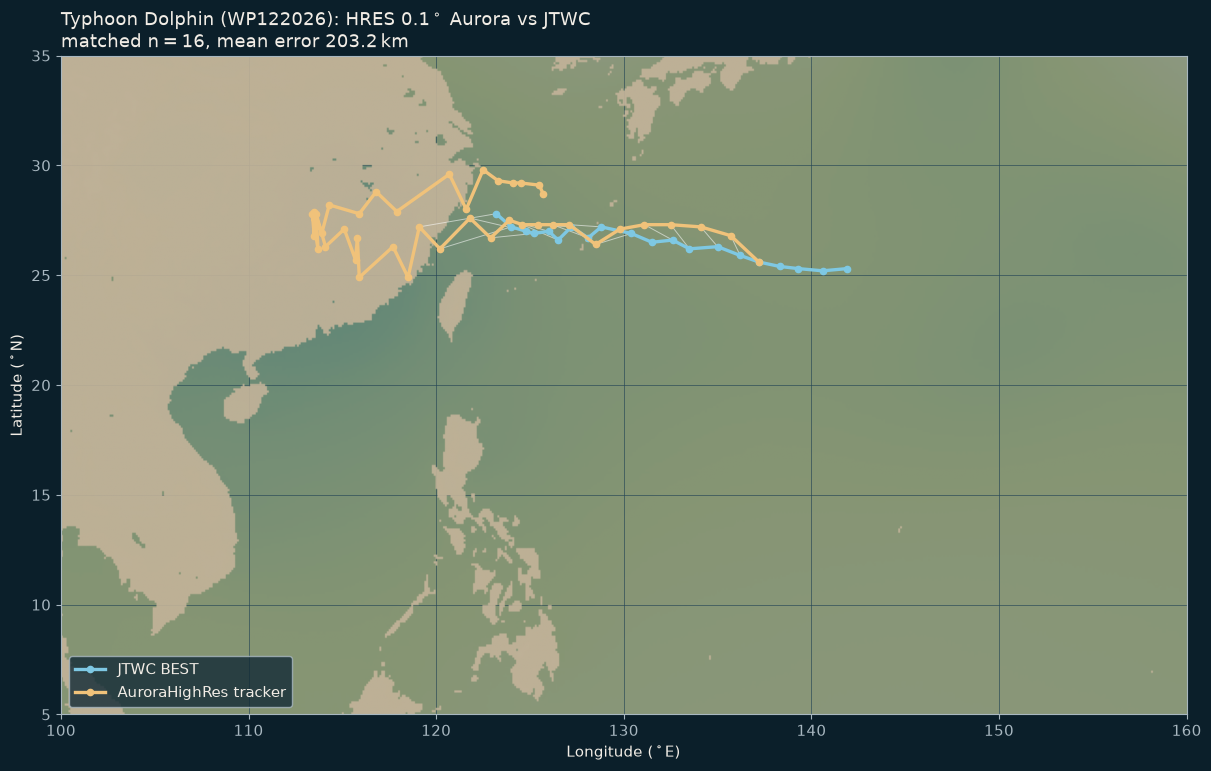

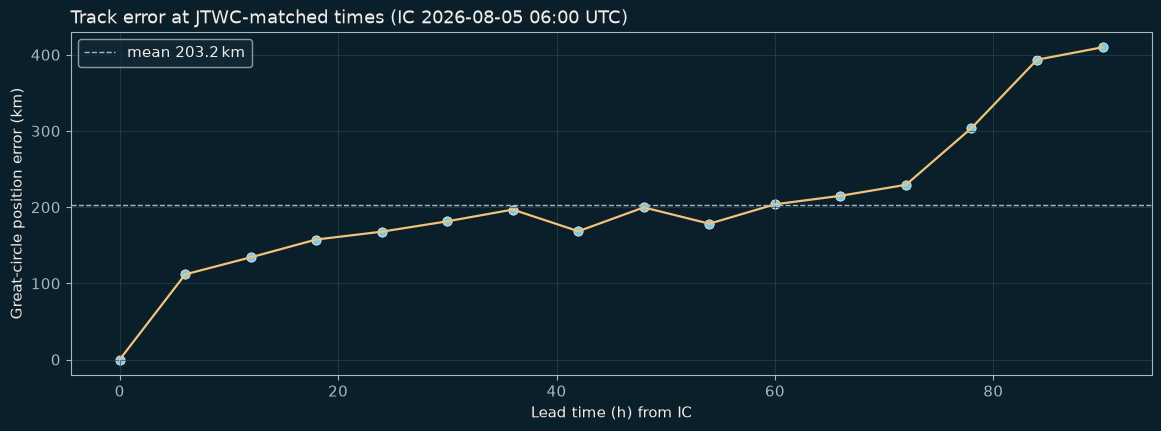

In [7]:
def haversine_km(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    r_earth_km = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(((lon2 - lon1 + 180.0) % 360.0) - 180.0)
    a = math.sin(dphi / 2.0) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2.0) ** 2
    return 2.0 * r_earth_km * math.asin(min(1.0, math.sqrt(a)))


aurora_cmp = track[["time", "lat", "lon", "lead_h", "grade"]].copy()
aurora_cmp["time"] = pd.to_datetime(aurora_cmp["time"]).dt.tz_localize(None)
jtwc_cmp = jtwc.copy()
jtwc_cmp["time"] = pd.to_datetime(jtwc_cmp["time"])

merged = aurora_cmp.merge(jtwc_cmp, on="time", how="inner", suffixes=("_aurora", "_jtwc"))
if merged.empty:
    print("No overlapping Aurora / JTWC times -- b-deck may not cover this IC window yet.")
else:
    merged["error_km"] = [
        haversine_km(la, lo, lj, oj)
        for la, lo, lj, oj in zip(
            merged["lat_aurora"], merged["lon_aurora"], merged["lat_jtwc"], merged["lon_jtwc"]
        )
    ]
    print(
        f"matched n={len(merged)}  "
        f"mean={merged['error_km'].mean():.1f} km  "
        f"median={merged['error_km'].median():.1f} km  "
        f"rmse={math.sqrt((merged['error_km'] ** 2).mean()):.1f} km  "
        f"max={merged['error_km'].max():.1f} km"
    )
    display(
        merged[
            ["time", "lead_h", "lat_aurora", "lon_aurora", "lat_jtwc", "lon_jtwc", "error_km", "wind_kt", "grade"]
        ].round({"lat_aurora": 2, "lon_aurora": 2, "lat_jtwc": 2, "lon_jtwc": 2, "error_km": 1})
    )

    AURORA_COLOR = "#F0C27A"
    JTWC_COLOR = "#7EC8E3"
    fig, ax = plt.subplots(figsize=(12.0, 7.6), constrained_layout=True)
    ax.imshow(msl_crop, extent=extent, origin="upper", aspect="auto", cmap=MSL_CMAP, vmin=940, vmax=1018, alpha=0.55, zorder=1)
    ax.imshow((lsm_crop >= 0.5).astype(float), extent=extent, origin="upper", aspect="auto", cmap=land_cmap, vmin=0, vmax=1, alpha=0.9, zorder=2)
    t0 = pd.Timestamp(VALID_TIME)
    t1 = pd.Timestamp(track["time"].iloc[-1])
    jtwc_window = jtwc_cmp[(jtwc_cmp["time"] >= t0 - pd.Timedelta(hours=24)) & (jtwc_cmp["time"] <= t1)]
    ax.plot(jtwc_window["lon"], jtwc_window["lat"], color=JTWC_COLOR, lw=2.4, marker="o", markersize=4.5, zorder=5, label="JTWC BEST")
    ax.plot(track["lon"], track["lat"], color=AURORA_COLOR, lw=2.4, marker="o", markersize=4.5, zorder=6, label="AuroraHighRes tracker")
    for _, row in merged.iterrows():
        ax.plot([row["lon_jtwc"], row["lon_aurora"]], [row["lat_jtwc"], row["lat_aurora"]], color="white", lw=0.7, alpha=0.55, zorder=4)
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_xlabel(r"Longitude ($^\circ$E)")
    ax.set_ylabel(r"Latitude ($^\circ$N)")
    ax.set_title(
        rf"{STORM_NAME_EN} ({STORM_ID_JTWC}): HRES $0.1^\circ$ Aurora vs JTWC"
        "\n"
        rf"matched $n={len(merged)}$, mean error ${merged['error_km'].mean():.1f}\,\mathrm{{km}}$",
        loc="left",
    )
    ax.legend(loc="lower left", facecolor="#122A36", edgecolor=MUTED, labelcolor=TEXT)
    ax.grid(True, color="#244556", lw=0.6, alpha=0.75)
    plt.show()

    fig, ax = plt.subplots(figsize=(11.5, 4.2), constrained_layout=True)
    ax.set_facecolor(SEA)
    ax.plot(merged["lead_h"], merged["error_km"], color=AURORA_COLOR, lw=1.6)
    ax.scatter(merged["lead_h"], merged["error_km"], c=JTWC_COLOR, s=45, edgecolors="white", linewidths=0.5)
    ax.axhline(merged["error_km"].mean(), color=MUTED, ls="--", lw=1.0, label=rf"mean ${merged['error_km'].mean():.1f}\,\mathrm{{km}}$")
    ax.set_xlabel(r"Lead time (h) from IC")
    ax.set_ylabel(r"Great-circle position error (km)")
    ax.set_title(rf"Track error at JTWC-matched times (IC {VALID_TIME.strftime('%Y-%m-%d %H:%M')} UTC)", loc="left")
    ax.grid(True, color="#244556", lw=0.6, alpha=0.8)
    ax.legend(loc="upper left", facecolor="#122A36", edgecolor=MUTED, labelcolor=TEXT)
    plt.show()

## 7. Shutdown

In [8]:
engine.close()
print("done")

done
